<a href="https://colab.research.google.com/github/davidgeraldi/Calculo-Numerico-UNIFESP/blob/main/atividade3_calculo_numerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico – Atividade prática III
**Métodos da bisseção, de Newton e da secante**

Notebook organizado em: (0) configuração, (1) implementação dos métodos, (2) aplicação e tabela de resultados, (3) animações em GIF.

### Critério de parada adotado
Em todos os métodos o algoritmo **só declara convergência quando as duas condições são satisfeitas ao mesmo tempo**:

- diferença entre aproximações sucessivas: $|x_{k+1}-x_k| < tol$
- resíduo: $|f(x_{k+1})| < tol$

(na bisseção, $|x_{k+1}-x_k|$ é a metade do comprimento do intervalo atual). Também há parada por falha em: $f(a)f(b)>0$ (bisseção), $|f'(x_k)|\approx 0$ (Newton), denominador $\approx 0$ (secante), valores não finitos, ou estouro de `max_iter`.

In [1]:
# ========== 0. CONFIGURAÇÃO (altere aqui sem mexer no resto) ==========
import math
from dataclasses import dataclass, field
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

TOL = 1e-6          # tolerância
MAX_ITER = 100      # número máximo de iterações
EPS = 1e-12         # limite para considerar derivada/denominador "zero"

## Parte 1 – Implementação dos métodos

In [2]:
@dataclass
class Resultado:
    """Resultado padronizado retornado pelos três métodos."""
    raiz: float                                   # aproximação final da raiz
    iteracoes: int                                # nº de iterações realizadas
    aproximacoes: list                            # aproximações (inclui os valores iniciais)
    convergiu: bool                               # True se atingiu o critério de parada
    mensagem: str                                 # explicação (convergência ou motivo da falha)
    passos: list = field(default_factory=list)    # dados de cada passo (usados nas animações)


def _parou(x_novo, x_ant, f, tol):
    """Critério de parada: |x_{k+1}-x_k| < tol E |f(x_{k+1})| < tol."""
    return abs(x_novo - x_ant) < tol and abs(f(x_novo)) < tol


def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    """Método da bisseção no intervalo [a, b]."""
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        return Resultado(float("nan"), 0, [], False,
                         "Falha: f(a)·f(b) > 0 (não há garantia de raiz no intervalo)")
    aprox, passos = [], []
    c_ant = a
    for k in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        passos.append(dict(a=a, b=b, c=c, fc=fc))
        aprox.append(c)
        # metade do intervalo = |x_{k+1} - x_k| na bisseção
        if (b - a) / 2 < tol and abs(fc) < tol or fc == 0:
            return Resultado(c, k, aprox, True, "Convergiu", passos)
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return Resultado(aprox[-1], max_iter, aprox, False,
                     "Falha: máximo de iterações atingido", passos)


def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER):
    """Método de Newton com derivada analítica df."""
    x = x0
    aprox, passos = [x0], []
    for k in range(1, max_iter + 1):
        fx, dfx = f(x), df(x)
        if abs(dfx) < EPS:
            return Resultado(x, k - 1, aprox, False,
                             f"Falha: f'(x) ≈ 0 em x = {x:.6g}", passos)
        x_novo = x - fx / dfx
        if not math.isfinite(x_novo):
            return Resultado(x, k - 1, aprox, False, "Falha: valor não finito (divergiu)", passos)
        passos.append(dict(x=x, fx=fx, dfx=dfx, xn=x_novo))
        aprox.append(x_novo)
        if _parou(x_novo, x, f, tol):
            return Resultado(x_novo, k, aprox, True, "Convergiu", passos)
        x = x_novo
    return Resultado(x, max_iter, aprox, False, "Falha: máximo de iterações atingido", passos)


def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER):
    """Método da secante com dois valores iniciais x0 e x1."""
    aprox, passos = [x0, x1], []
    for k in range(1, max_iter + 1):
        f0, f1 = f(x0), f(x1)
        den = f1 - f0
        if abs(den) < EPS:
            return Resultado(x1, k - 1, aprox, False,
                             "Falha: denominador f(x1)-f(x0) ≈ 0", passos)
        x2 = x1 - f1 * (x1 - x0) / den
        if not math.isfinite(x2):
            return Resultado(x1, k - 1, aprox, False, "Falha: valor não finito (divergiu)", passos)
        passos.append(dict(x0=x0, f0=f0, x1=x1, f1=f1, x2=x2))
        aprox.append(x2)
        if _parou(x2, x1, f, tol):
            return Resultado(x2, k, aprox, True, "Convergiu", passos)
        x0, x1 = x1, x2
    return Resultado(x1, max_iter, aprox, False, "Falha: máximo de iterações atingido", passos)

## Parte 2 – Aplicação e análise
Para trocar de função, basta editar o dicionário `FUNCOES` (função, derivada e valores iniciais).

In [3]:
FUNCOES = {
    "f1(x) = x² − 2": dict(
        f=lambda x: x**2 - 2,
        df=lambda x: 2 * x,
        intervalo=(1, 2), x0_newton=1.5, par_secante=(1, 2)),
    "f2(x) = x³ − x − 2": dict(
        f=lambda x: x**3 - x - 2,
        df=lambda x: 3 * x**2 - 1,
        intervalo=(1, 2), x0_newton=1.5, par_secante=(1, 2)),
    "f3(x) = e^(−x) − x": dict(
        f=lambda x: math.exp(-x) - x,
        df=lambda x: -math.exp(-x) - 1,
        intervalo=(0, 1), x0_newton=0.5, par_secante=(0, 1)),
    "f4(x) = x³ − 2x + 2": dict(
        f=lambda x: x**3 - 2 * x + 2,
        df=lambda x: 3 * x**2 - 2,
        intervalo=(-2, -1), x0_newton=-2, par_secante=(-2, -1)),
}

# Testes extras (para discutir falhas): (nome da função, método, valores iniciais)
TESTES_EXTRAS = [
    ("f4(x) = x³ − 2x + 2", "Newton", (0,)),       # oscila 0 → 1 → 0 → ... (ciclo)
    ("f1(x) = x² − 2", "Newton", (0,)),            # f'(0) = 0
    ("f1(x) = x² − 2", "Bisseção", (2, 3)),        # f(a)f(b) > 0
    ("f1(x) = x² − 2", "Secante", (-1, 1)),        # f(-1) = f(1) → denominador zero
]

def executar(nome, metodo, iniciais, tol=TOL, max_iter=MAX_ITER):
    """Roda um método para uma função e valores iniciais dados."""
    f, df = FUNCOES[nome]["f"], FUNCOES[nome]["df"]
    if metodo == "Bisseção":
        return bissecao(f, *iniciais, tol, max_iter)
    if metodo == "Newton":
        return newton(f, df, *iniciais, tol, max_iter)
    return secante(f, *iniciais, tol, max_iter)


def montar_tabela(casos):
    linhas = []
    for nome, metodo, ini in casos:
        r = executar(nome, metodo, ini)
        f = FUNCOES[nome]["f"]
        ok = r.convergiu
        linhas.append({
            "Função": nome.split(" = ")[0],
            "Método": metodo,
            "Valores iniciais": str(ini if len(ini) > 1 else ini[0]),
            "Raiz aproximada": f"{r.raiz:.8f}" if not math.isnan(r.raiz) else "—",
            "|f(x)| final": f"{abs(f(r.raiz)):.2e}" if not math.isnan(r.raiz) else "—",
            "Iterações/resultado": f"{r.iteracoes} (convergiu)" if ok else r.mensagem,
        })
    return pd.DataFrame(linhas)


# casos principais (valores sugeridos na tabela do enunciado)
casos = []
for nome, d in FUNCOES.items():
    casos += [(nome, "Bisseção", d["intervalo"]),
              (nome, "Newton", (d["x0_newton"],)),
              (nome, "Secante", d["par_secante"])]

tabela = montar_tabela(casos)
tabela

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x),Bisseção,"(1, 2)",1.41421366,2.69e-07,21 (convergiu)
1,f1(x),Newton,1.5,1.41421356,4.44e-16,4 (convergiu)
2,f1(x),Secante,"(1, 2)",1.41421356,8.88e-16,6 (convergiu)
3,f2(x),Bisseção,"(1, 2)",1.52137971,1.45e-08,22 (convergiu)
4,f2(x),Newton,1.5,1.52137971,4.53e-14,3 (convergiu)
5,f2(x),Secante,"(1, 2)",1.52137971,1.84e-14,7 (convergiu)
6,f3(x),Bisseção,"(0, 1)",0.56714344,2.35e-07,20 (convergiu)
7,f3(x),Newton,0.5,0.56714329,4.44e-15,3 (convergiu)
8,f3(x),Secante,"(0, 1)",0.56714329,1.24e-13,5 (convergiu)
9,f4(x),Bisseção,"(-2, -1)",-1.76929235,2.55e-09,21 (convergiu)


In [4]:
# Testes extras para a análise de falhas / sensibilidade aos valores iniciais
montar_tabela(TESTES_EXTRAS)

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f4(x),Newton,0,0.00000000,2.00e+00,Falha: máximo de iterações atingido
1,f1(x),Newton,0,0.00000000,2.00e+00,Falha: f'(x) ≈ 0 em x = 0
2,f1(x),Bisseção,"(2, 3)",—,—,Falha: f(a)·f(b) > 0 (não há garantia de raiz ...
3,f1(x),Secante,"(-1, 1)",1.00000000,1.00e+00,Falha: denominador f(x1)-f(x0) ≈ 0


In [5]:
# Salva a tabela (útil para colar no mathcha.io)
tabela.to_csv("tabela_resultados.csv", index=False)
print(tabela.to_markdown(index=False) if hasattr(tabela, "to_markdown") else tabela)

| Função   | Método   | Valores iniciais   |   Raiz aproximada |   |f(x)| final | Iterações/resultado   |
|:---------|:---------|:-------------------|------------------:|---------------:|:----------------------|
| f1(x)    | Bisseção | (1, 2)             |          1.41421  |       2.69e-07 | 21 (convergiu)        |
| f1(x)    | Newton   | 1.5                |          1.41421  |       4.44e-16 | 4 (convergiu)         |
| f1(x)    | Secante  | (1, 2)             |          1.41421  |       8.88e-16 | 6 (convergiu)         |
| f2(x)    | Bisseção | (1, 2)             |          1.52138  |       1.45e-08 | 22 (convergiu)        |
| f2(x)    | Newton   | 1.5                |          1.52138  |       4.53e-14 | 3 (convergiu)         |
| f2(x)    | Secante  | (1, 2)             |          1.52138  |       1.84e-14 | 7 (convergiu)         |
| f3(x)    | Bisseção | (0, 1)             |          0.567143 |       2.35e-07 | 20 (convergiu)        |
| f3(x)    | Newton   | 0.5                |  

### Análise

**1. Iterações e Ordem de Convergência:**

Observando a tabela de resultados para os casos principais:

*   **Método da Bisseção:** Requer significativamente mais iterações para convergir em comparação com Newton e Secante. Por exemplo, para `f1(x)`, a Bisseção precisou de 21 iterações, enquanto Newton precisou de 4 e Secante de 6. Isso é esperado, pois a Bisseção tem uma convergência linear (o erro é reduzido por um fator constante a cada iteração), enquanto Newton e Secante têm convergência superlinear (Newton quadrática, Secante de ordem aproximo de 1.618).
*   **Método de Newton:** Geralmente é o método que converge mais rapidamente, com o menor número de iterações (3 a 4 para a maioria das funções). Sua convergência quadrática faz com que o número de dígitos significativos corretos dobre a cada iteração, uma vez perto da raiz.
*   **Método da Secante:** Apresenta uma taxa de convergência intermediária entre a Bisseção e Newton (5 a 7 iterações para a maioria das funções). Embora não seja tão rápido quanto Newton, ele não requer o cálculo da derivada, o que pode ser uma vantagem em funções cuja derivada é complexa ou desconhecida.

**2. Casos de Falha e Sensibilidade aos Valores Iniciais (TESTES_EXTRAS):**

*   **Ciclo de Newton em `f4(x) = x³ − 2x + 2` com `x0 = 0`:** A tabela mostra "Falha: máximo de iterações atingido". Este é um exemplo clássico de divergência por oscilação ou ciclo. Partindo de `x0 = 0`, as aproximações podem alternar entre valores, como `0 → 1 → 0 → ...`, sem convergir para a raiz. Isso ocorre quando a tangente intercepta o eixo x em um ponto que leva de volta ao ponto inicial ou a um ciclo de pontos.

*   **Caso `f'(x0) ≈ 0` para `f1(x) = x² − 2` com `x0 = 0` (Newton):** A tabela indica "Falha: f'(x) ≈ 0 em x = 0". Para a função `f(x) = x² - 2`, a derivada é `f'(x) = 2x`. Em `x0 = 0`, `f'(x0) = 0`. O método de Newton envolve a divisão por `f'(x_k)`. Quando a derivada é zero ou muito próxima de zero, a inclinação da tangente é horizontal ou quase horizontal, levando a um próximo valor `x_{k+1}` que pode ser muito distante ou indefinido, causando divergência ou instabilidade.

*   **Bisseção quando `f(a)f(b) > 0` para `f1(x) = x² − 2` com `(2, 3)`:** A tabela registra "Falha: f(a)·f(b) > 0 (não há garantia de raiz no intervalo)". O método da Bisseção exige que o sinal de `f(a)` e `f(b)` sejam opostos (ou seja, `f(a)f(b) < 0`) para garantir que haja pelo menos uma raiz no intervalo `[a, b]`. Se ambos tiverem o mesmo sinal, não há garantia da existência de uma raiz real no intervalo, e o método não pode ser aplicado.

*   **Secante quando `f(x0) = f(x1)` para `f1(x) = x² − 2` com `(-1, 1)`:** A tabela mostra "Falha: denominador f(x1)-f(x0) ≈ 0". Para `f(x) = x² - 2`, temos `f(-1) = (-1)² - 2 = -1` e `f(1) = (1)² - 2 = -1`. Assim, `f(x1) - f(x0) = f(1) - f(-1) = -1 - (-1) = 0`. O método da Secante envolve a divisão por `f(x1) - f(x0)`. Se o denominador for zero ou muito próximo de zero, o método falha, pois a linha secante se torna horizontal ou quase horizontal, não interceptando o eixo x ou interceptando-o muito longe.

*   **Intervalos para `f4(x) = x³ − 2x + 2`:** Esta função tem uma única raiz real em `x ≈ -1.769`. Conforme visto nos resultados principais, um intervalo como `[-2, -1]` funciona bem para a Bisseção, pois `f(-2) = -2` e `f(-1) = 3`, garantindo uma raiz. No entanto, um intervalo como `[0, 1]` não funcionaria para a Bisseção, pois `f(0) = 2` e `f(1) = 1`, ambos com o mesmo sinal, indicando que não há raiz nesse intervalo (ou há um número par de raízes, o que não garante a aplicação do método).

**Conclusão:**

Os métodos de Newton e da Secante são consideravelmente mais eficientes em termos de número de iterações quando convergem, mas são mais sensíveis à escolha dos valores iniciais e a condições específicas (como `f'(x) ≈ 0` ou `f(x0) ≈ f(x1)`). O método da Bisseção, embora mais lento, é robusto e sempre converge para uma raiz se o intervalo inicial for bem escolhido (isto é, `f(a)f(b) < 0`). A escolha do método ideal depende da função, da disponibilidade de sua derivada e da tolerância aceitável.

## Parte 3 – Animações (GIF)

In [6]:
def _limites(f, r, margem=0.35):
    """Calcula janela de visualização a partir das aproximações."""
    xs = [x for x in r.aproximacoes if math.isfinite(x)]
    for p in r.passos:
        xs += [v for k, v in p.items() if k in ("a", "b") and math.isfinite(v)]
    lo, hi = min(xs), max(xs)
    pad = max(0.4, margem * (hi - lo))
    xmin, xmax = lo - pad, hi + pad
    g = np.linspace(xmin, xmax, 400)
    y = np.array([f(v) for v in g])
    ypad = 0.1 * (y.max() - y.min() + 1e-9)
    return xmin, xmax, min(y.min(), 0) - ypad, max(y.max(), 0) + ypad


def animar(nome, metodo, iniciais, arquivo, fps=1.2, tol=TOL, max_iter=MAX_ITER, max_quadros=30):
    """Gera a animação (GIF) de um método aplicado a uma função."""
    f = FUNCOES[nome]["f"]
    r = executar(nome, metodo, iniciais, tol, max_iter)
    if not r.passos:
        print(f"Sem passos para animar ({r.mensagem}).")
        return r
    xmin, xmax, ymin, ymax = _limites(f, r)
    xg = np.linspace(xmin, xmax, 500)
    yg = [f(v) for v in xg]
    n = min(len(r.passos), max_quadros)   # limita o nº de quadros (útil em casos que não convergem)

    fig, ax = plt.subplots(figsize=(8, 5), dpi=90)

    def quadro(i):
        ax.clear()
        ax.plot(xg, yg, color="tab:blue", label="f(x)")
        ax.axhline(0, color="black", lw=1)
        ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.3)
        p = r.passos[i]

        if metodo == "Bisseção":
            ax.axvspan(p["a"], p["b"], color="orange", alpha=0.25, label="intervalo [a, b]")
            for v in (p["a"], p["b"]):
                ax.plot([v, v], [0, f(v)], "k--", lw=0.8)
                ax.plot(v, f(v), "ks", ms=5)
            ax.plot(p["c"], 0, "ro", label="ponto médio c")
            ax.plot(p["c"], p["fc"], "ro", ms=4)
            atual, res = p["c"], abs(p["fc"])
            extra = f"[a, b] = [{p['a']:.5f}, {p['b']:.5f}]\ncomprimento = {p['b']-p['a']:.2e}"

        elif metodo == "Newton":
            for q in r.passos[:i]:                       # passos anteriores (esmaecidos)
                ax.plot(q["x"], q["fx"], "o", color="gray", alpha=0.4, ms=4)
            x, fx, dfx, xn = p["x"], p["fx"], p["dfx"], p["xn"]
            xs = np.array([min(x, xn) - 0.3 * abs(xn - x) - 0.1, max(x, xn) + 0.3 * abs(xn - x) + 0.1])
            ax.plot(xs, fx + dfx * (xs - x), "r-", lw=1.5, label="reta tangente")
            ax.plot([x, x], [0, fx], "k:", lw=0.8)
            ax.plot(x, fx, "ko", label=f"(x_k, f(x_k))")
            ax.plot(xn, 0, "go", label="x_{k+1}")
            atual, res = xn, abs(f(xn))
            extra = f"x_k = {x:.6f}\nf'(x_k) = {dfx:.4g}"

        else:  # Secante
            for q in r.passos[:i]:
                ax.plot([q["x0"], q["x1"]], [q["f0"], q["f1"]], "o", color="gray", alpha=0.4, ms=4)
            x0, f0, x1, f1, x2 = p["x0"], p["f0"], p["x1"], p["f1"], p["x2"]
            m = (f1 - f0) / (x1 - x0)
            xs = np.array([min(x0, x1, x2) - 0.2, max(x0, x1, x2) + 0.2])
            ax.plot(xs, f1 + m * (xs - x1), "r-", lw=1.5, label="reta secante")
            ax.plot([x0, x1], [f0, f1], "ko", label="pontos usados")
            ax.plot(x2, 0, "go", label="x_{k+1}")
            atual, res = x2, abs(f(x2))
            extra = f"x_(k-1) = {x0:.5f}\nx_k = {x1:.5f}"

        ax.set_title(f"{metodo} – {nome}")
        ax.text(0.02, 0.97,
                f"Iteração {i+1}/{n}\nx atual = {atual:.8f}\n|f(x)| = {res:.2e}\n{extra}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
        if i == n - 1 and n == len(r.passos):
            ax.text(0.98, 0.03, r.mensagem, transform=ax.transAxes, ha="right", fontsize=10,
                    color="green" if r.convergiu else "red")
        ax.legend(loc="lower right" if i < n - 1 else "lower left", fontsize=8)

    frames = list(range(n)) + [n - 1] * 3       # repete o último quadro (pausa no final)
    anim = FuncAnimation(fig, quadro, frames=frames, interval=1000 / fps)
    anim.save(arquivo, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"GIF salvo: {arquivo}  ({r.mensagem}, {r.iteracoes} iterações)")
    return r

In [7]:
# Gere quantas combinações quiser (o enunciado pede pelo menos 3)
ANIMACOES = [
    ("f1(x) = x² − 2",     "Bisseção", (1, 2),  "anim_bissecao_f1.gif"),
    ("f2(x) = x³ − x − 2", "Newton",   (1.5,),  "anim_newton_f2.gif"),
    ("f3(x) = e^(−x) − x", "Secante",  (0, 1),  "anim_secante_f3.gif"),
    ("f4(x) = x³ − 2x + 2", "Newton",  (0,),    "anim_newton_f4_ciclo.gif"),  # caso de falha (bônus)
]
for nome, metodo, ini, arq in ANIMACOES:
    animar(nome, metodo, ini, arq)

GIF salvo: anim_bissecao_f1.gif  (Convergiu, 21 iterações)
GIF salvo: anim_newton_f2.gif  (Convergiu, 3 iterações)
GIF salvo: anim_secante_f3.gif  (Convergiu, 5 iterações)
GIF salvo: anim_newton_f4_ciclo.gif  (Falha: máximo de iterações atingido, 100 iterações)


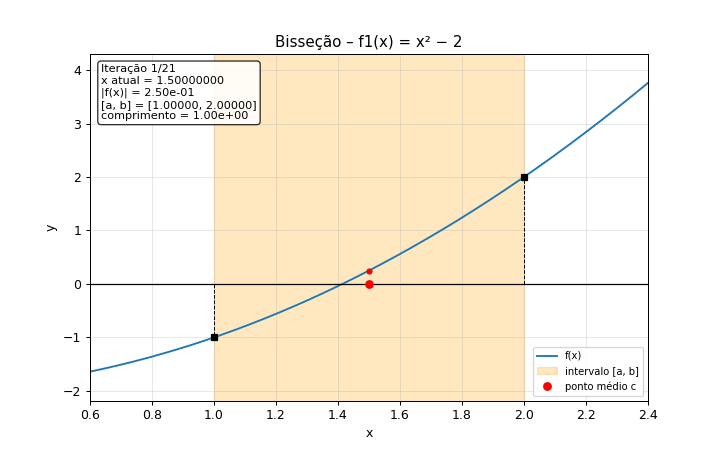

In [8]:
# Visualizar um GIF dentro do Colab
from IPython.display import Image, display
display(Image("anim_bissecao_f1.gif"))

In [9]:
# Baixar todos os arquivos gerados (Colab)
try:
    from google.colab import files
    import glob, zipfile
    with zipfile.ZipFile("entrega_atividade3.zip", "w") as z:
        for arq in glob.glob("*.gif") + ["tabela_resultados.csv"]:
            z.write(arq)
    files.download("entrega_atividade3.zip")
except ImportError:
    print("Fora do Colab: os arquivos estão na pasta atual.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>